### Chargement et Prétraitement du Dataset

**Importer les bibliothèques nécessaires**


In [2]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

**Charger les images du dataset et vérifier leurs extensions (jpeg, jpg, bmp, png). Supprimer celles qui ne correspondent pas**

In [3]:
data_original='../data/raw/Data'
labels=list()
images=list()
extensions=("jpeg", "jpg", "bmp", "png")


for dossier in os.listdir(data_original) :
    dossier_path=os.path.join(data_original,dossier)
    if os.path.isdir(dossier_path):
        for img in os.listdir(dossier_path):
            img_path= os.path.join(dossier_path,img)
            if not img.lower().endswith(extensions):
                print(f"Fichier supprimé (extension invalide) : {img}")
                os.remove(img_path)
                continue
            try:
                img=cv2.imread(img_path)
                img=cv2.resize(img,(224,224))
                images.append(img)
                labels.append(dossier)
            except:
                print(f"Erreur avec l'image: {img}")
            

 **Convertir les listes images et étiquettes en tableaux NumPy pour les rendre exploitables par le modèle CNN**


In [4]:
X=np.array(images,dtype="float32")
Y=np.array(labels)
print(X.shape)
print(Y)


(7023, 224, 224, 3)
['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


**Afficher graphiquement le nombre d’images dans chaque classe**

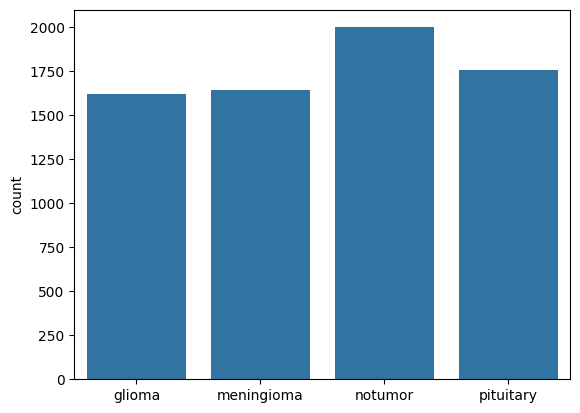

In [8]:
sns.countplot(x=Y)
plt.show()


**Montrer un échantillon d’images par classe**

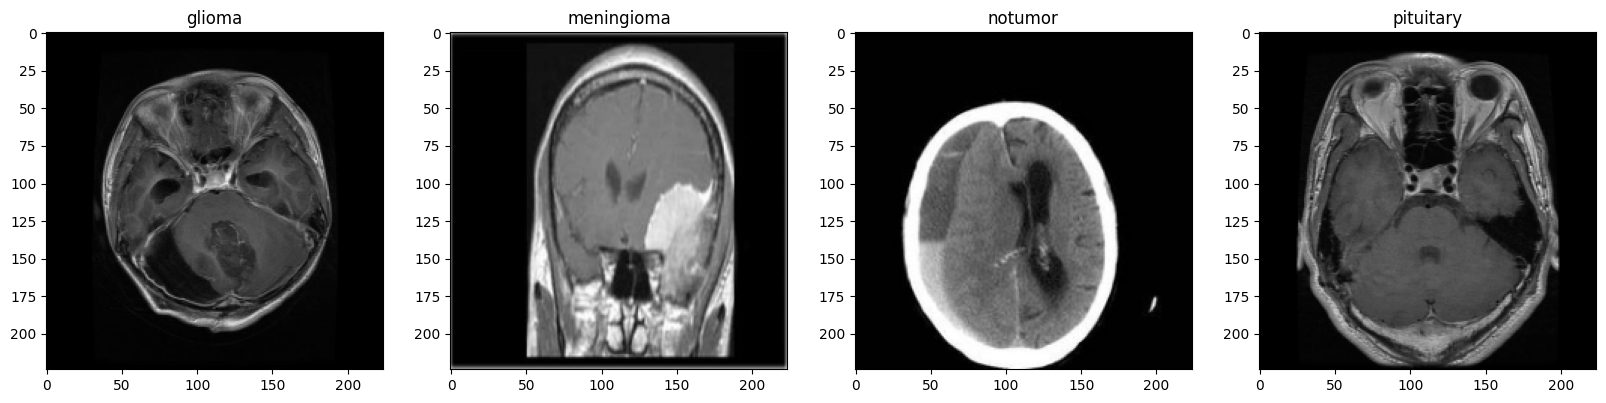

In [6]:
classes_name=np.unique(labels)
plt.figure(figsize=(20,15))
for i,classe in enumerate(classes_name):
    idx=labels.index(classe)
    plt.subplot(1,len(classes_name),i+1)
    plt.imshow(cv2.cvtColor(images[idx],cv2.COLOR_BGR2RGB))
    plt.title(classe)
    
plt.show()


**Vérification d’équilibre entre les classes et appliquer un rééquilibrage si nécessaire**


In [7]:
unique_classes, counts = np.unique(labels, return_counts=True)

for classe, count in zip(unique_classes, counts):
    print(f"{classe} : {count} images")

glioma : 1621 images
meningioma : 1645 images
notumor : 2000 images
pituitary : 1757 images


In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator



datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
unique, counts = np.unique(Y, return_counts=True)
class_counts = dict(zip(unique, counts))
print("Avant rééquilibrage :", class_counts)

X_balanced, y_balanced = [], []

target = 2000  

for label in unique:
    X_class = X[Y == label]
    print("X_class ====>", X_class)
    count = len(X_class)
    X_balanced.append(X_class)
    y_balanced.append(np.full(target, label))

    if count < target:
        needed = target - count
        augmented = []
        for x in datagen.flow(X_class, batch_size=1):
            augmented.append(X[0])
            if len(augmented) >= needed:
                break
        X_balanced[-1] = np.concatenate((X_class, np.array(augmented)), axis=0)

X_balanced = np.concatenate(X_balanced)
y_balanced = np.concatenate(y_balanced)
np.save("../data/processed/X_balanced.npy", X_balanced)
np.save("../data/processed/y_balanced.npy", y_balanced)
print("Après rééquilibrage :", {lbl: sum(y_balanced == lbl) for lbl in unique})


Avant rééquilibrage : {np.str_('glioma'): np.int64(1621), np.str_('meningioma'): np.int64(1645), np.str_('notumor'): np.int64(2000), np.str_('pituitary'): np.int64(1757)}
X_class ====> [[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]

In [9]:
unique, counts = np.unique(y_balanced, return_counts=True)
print(unique)
print(counts)

['glioma' 'meningioma' 'notumor' 'pituitary']
[2000 2000 2000 2000]


**Transformer les étiquettes textuelles en format numérique (ex. avec LabelEncoder ou to_categorical)**


In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import joblib

le = LabelEncoder()
y_encoded = le.fit_transform(y_balanced)

y_final = to_categorical(y_encoded)

joblib.dump(le, "label_encoder.pkl")
print("Encodeur sauvegardé !")

Encodeur sauvegardé !


**Diviser les données en ensembles d’entraînement et de test**


In [25]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_final, test_size=0.2, random_state=42, stratify=y_final
)


**Normaliser les valeurs des pixels dans la plage [0, 1]**


In [26]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

np.savez('../data/processed/dataset_prepared.npz', 
         X_train=X_train, X_test=X_test, 
         y_train=y_train, y_test=y_test)
